   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

RESULTADOS

R2: 0.926380103264485


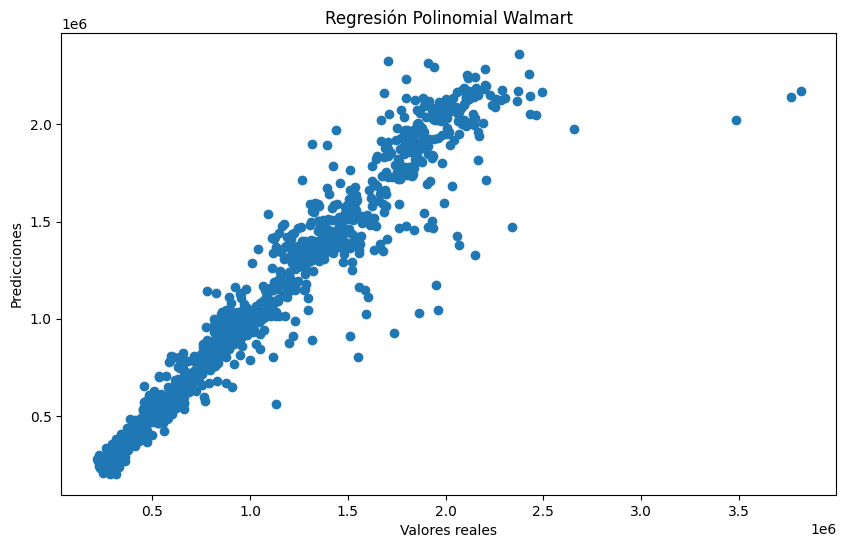

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



dataset = pd.read_csv("Walmart.csv")

print(dataset.head())



dataset = pd.get_dummies(dataset,columns=['Store'],drop_first=True)



X = dataset.drop(columns=['Weekly_Sales', 'Date'])



y = dataset['Weekly_Sales']


X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X,y,test_size=0.2,random_state=42)


normalizador = StandardScaler()

X_entrenamiento_normalizado = normalizador.fit_transform(X_entrenamiento)

X_prueba_normalizado = normalizador.transform( X_prueba)


polinomio = PolynomialFeatures(degree=2)

X_entrenamiento_polinomial = polinomio.fit_transform(X_entrenamiento_normalizado)

X_prueba_polinomial = polinomio.transform(X_prueba_normalizado)



modelo = LinearRegression()

modelo.fit(X_entrenamiento_polinomial,y_entrenamiento)


predicciones = modelo.predict(X_prueba_polinomial)



r2 = r2_score(y_prueba,predicciones)


print("\nRESULTADOS\n")


print("R2:", r2)


plt.figure(figsize=(10,6))

plt.scatter(y_prueba,predicciones)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title("Regresión Polinomial Walmart")

plt.show()

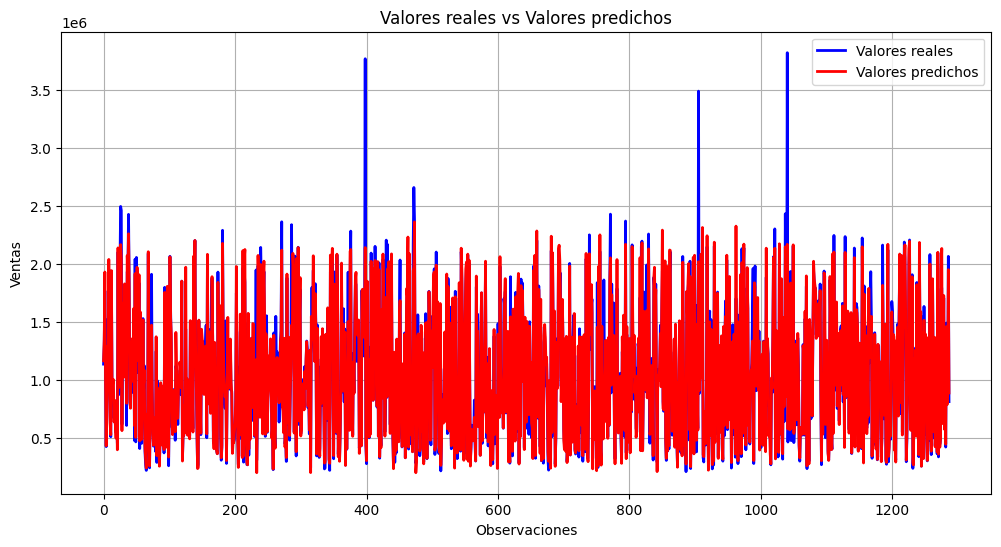

In [4]:

plt.figure(figsize=(12,6))

# Valores reales
plt.plot(y_prueba.values,color='blue',label='Valores reales',linewidth=2)

# Valores predichos
plt.plot( predicciones,color='red',label='Valores predichos',linewidth=2)

# Etiquetas
plt.xlabel("Observaciones")
plt.ylabel("Ventas")

# Título
plt.title("Valores reales vs Valores predichos")

# Leyenda
plt.legend()

# Cuadrícula
plt.grid(True)

# Mostrar gráfica
plt.show()

In [6]:

nueva_semana = pd.DataFrame({

    'Temperature': [25],
    'Fuel_Price': [3.2],
    'CPI': [220],
    'Unemployment': [7],
    'Holiday_Flag': [1],

    # VARIABLES ONE HOT DE STORE
    'Store_2': [0],
    'Store_3': [0],
    'Store_4': [0],
    'Store_5': [1],

    # El resto de tiendas en 0
})


nueva_semana = nueva_semana.reindex(columns=X.columns,fill_value=0)


nueva_semana_normalizada = normalizador.transform(nueva_semana)


nueva_semana_polinomial = polinomio.transform(nueva_semana_normalizada)


prediccion = modelo.predict(nueva_semana_polinomial)


print("\nVENTAS PREDICHAS:")

print(prediccion[0])


VENTAS PREDICHAS:
434529.42232885864
